# Get Cross Section $\sigma$ = $pp \to S \to \gamma \chi \bar \chi $ 

In [234]:
# sys.path.append('/opt/apps/lhapdf/lib/python3.10/site-packages')

In [235]:
import lhapdf

In [236]:
p = lhapdf.mkPDF("CT10nlo", 0)

LHAPDF 6.5.5 loading /cvmfs/sft.cern.ch/lcg/external/lhapdfsets/current/CT10nlo/CT10nlo_0000.dat
CT10nlo PDF set, member #0, version 4; LHAPDF ID = 11000


In [237]:
p = lhapdf.mkPDF("NNPDF23_lo_as_0130_qed", 0)


LHAPDF 6.5.5 loading /cvmfs/sft.cern.ch/lcg/external/lhapdfsets/current/NNPDF23_lo_as_0130_qed/NNPDF23_lo_as_0130_qed_0000.dat
NNPDF23_lo_as_0130_qed PDF set, member #0, version 1; LHAPDF ID = 247000


In [238]:
# import utils.colorb_2D as cb2d
# import models.sigma0_xsections as sig0
import sys, os
sys.path.append('../')
import app.models.general_parameters as gp
# import app.models.relic_density_calc as ohm
import app.models.radiative_factorization as hp
import app.models.pdf_integration as qcd
import app.models.sigma0_xsections as sig0
#import app.utils.colorb_2D as cb2d
# import lhapdf 

import numpy as np
import fortran_quad
from functools import partial

In [239]:
import numpy as np

step = 100
dM = 0.01 # TeV
dmx = 0.005 # TeV 
#Mediator mass [Tev] # 
Mmed_min = 0.001
Mmed_max = 5.1
M_QUARK = 1E-6 ## SM fermion mass is negligible

Mmed_arr = np.arange(Mmed_min, Mmed_max, dM)
# DM particle mass [Tev] #
mx_min = 0.001
mx_max = 5.1
mx_arr = np.arange(mx_min, mx_max, dmx)
# Define a grid
Mmed_grid, mx_grid = np.meshgrid(Mmed_arr, mx_arr) # grid formation for plot
## CM total energy (14 TeV for HL-LHC)
smax = (3)**2  

# Couplings:
g_ps_psi = 0.25 # pseudo-scalar coupling from Mmed to SM
g_s_psi = 0.25 # scalar coupling from Mmed to SM
ALPH = (1/137)    # QED coupling constant 
g_ps_chi = 1 # pseudo-scalar coupling from Mmed to DM 
g_s_chi = 1 # scalar coupling from Mmed to DM

In [240]:

# ↑ Copy from the last output and do some tweaks

import numpy as np
import numba as nb
np.seterr(invalid='ignore')

@np.vectorize                     
def scalar_mediator_decay(
                          M_med: float | np.ndarray = np.nan,
                          m_f: float | np.ndarray = np.nan,
                          g_s_psi: float | np.ndarray = np.nan,
                          dm_type: str = 'fermion'
                          ) -> float | np.ndarray:
    
    if dm_type == 'scalar':
        return g_s_psi**2*np.sqrt(1 - 4*m_f**2/M_med**2)/(np.pi*M_med)
    
    elif dm_type == 'fermion':

        return (1/16)*g_s_psi**2*np.sqrt(1 - 4*m_f**2/M_med**2)*(M_med**2 - 4*m_f**2)/(np.pi*M_med)
    
    elif dm_type == 'vector':
        return (1/64)*g_s_psi**2*np.sqrt(1 - 4*m_f**2/M_med**2)*(M_med**4 - 8*M_med**2*m_f**2 + 16*m_f**4)/(np.pi*M_med*m_f**4)
    
    elif dm_type == 'sm':
        Nf = 18
        return Nf * (1/16)*g_s_psi**2*np.sqrt(1 - 4*m_f**2/M_med**2)*(M_med**2 - 4*m_f**2)/(np.pi*M_med)
    
    else:
        raise Exception



@np.vectorize
def scalar_mediator_xsec(
                          s : float | np.ndarray = np.nan,
                          M_med: float | np.ndarray = np.nan,
                          m_f: float | np.ndarray = np.nan,
                          g_s_psi: float | np.ndarray = np.nan,
                          g_ps_psi: float | np.ndarray = np.nan,
                          g_s_chi: float | np.ndarray = np.nan,
                          g_ps_chi: float | np.ndarray = np.nan,
                          dm_type: str = "",
                          ) -> float | np.ndarray:
    

    g_ps_psi = g_s_psi # Equal couplings for scalar and pseudo-scalar mediators
    g_ps_chi = g_s_chi # Equal couplings for scalar and pseudo-scalar mediators
    Bi = scalar_mediator_decay(M_med, M_QUARK, g_ps_psi, 'sm') # Initial states branching ratio
    Bf = scalar_mediator_decay(M_med, m_f, g_ps_chi, dm_type) # Final states branching ratio
    
    Gamma = Bi + Bf # Gamma Decay as the sum of the branching ratios
    
    if dm_type == 'scalar':
        return 16*g_s_chi**2*(g_ps_psi**2 + g_s_psi**2)*np.sqrt(-4*m_f**2 + s)/(np.sqrt(s)*(Gamma**2*M_med**2 + M_med**4 - 2*M_med**2*s + s**2))
    
    elif dm_type == 'fermion':
        return (1/2)*np.sqrt(-4*m_f**2 + s)*(-4*g_s_chi**2*m_f**2*(g_ps_psi**2 + g_s_psi**2) + s*(g_ps_chi**2*g_ps_psi**2 + g_ps_chi**2*g_s_psi**2 + g_ps_psi**2*g_s_chi**2 + g_s_chi**2*g_s_psi**2))/(np.sqrt(s)*(Gamma**2*M_med**2 + M_med**4 - 2*M_med**2*s + s**2))

    elif dm_type == 'vector':
        return (3/4)*g_s_chi**2*(g_ps_psi**2 + g_s_psi**2)*np.sqrt(-4*m_f**2 + s)/(np.sqrt(s)*(Gamma**2*M_med**2 + M_med**4 - 2*M_med**2*s + s**2))

    else:
        raise Exception 
        


In [241]:
## Hardphoton

@np.vectorize
def integrand_xg(xg: float = np.nan, 
                 s: float  = np.nan, 
                 M_med: float  = np.nan, 
                 m_f: float  = np.nan, 
                 g_s_psi: float  = np.nan, 
                 g_ps_psi: float  = np.nan, 
                 g_s_chi: float  = np.nan, 
                 g_ps_chi: float  = np.nan, 
                 dm_type: str = 'fermion'):

    preterm   = 1 / xg
    integrand = (1 - (xg) + ((xg**2) / 2))
    sigcorr = scalar_mediator_xsec( 
                        s = s*(1-xg),
                        M_med = M_med,
                        m_f = m_f,
                        g_s_psi = g_s_psi,
                        g_ps_psi = g_ps_psi,
                        g_s_chi = g_s_chi,
                        g_ps_chi = g_ps_chi ,
                        dm_type = dm_type) / scalar_mediator_xsec(\
                        s = s,
                        M_med = M_med,
                        m_f = m_f,
                        g_s_psi = g_s_psi,
                        g_ps_psi = g_ps_psi,
                        g_s_chi = g_s_chi,
                        g_ps_chi = g_ps_chi,
                        dm_type = dm_type) 
    
    result    = preterm * integrand * sigcorr
    return result

# def i_argument(x):
#     result = integrand_xg(x, s, mq, Mmed, mx, gr, gl, gx, sig0)
#     return result


@np.vectorize
def HPhsig(s: float  = np.nan, 
            M_med: float  = np.nan, 
            m_f: float  = np.nan, 
            g_s_psi: float  = np.nan, 
            g_ps_psi: float  = np.nan, 
            g_s_chi: float  = np.nan, 
            g_ps_chi: float  = np.nan, 
            dm_type: str = 'fermion'):
    
    '''Hard-photon factorization'''
    
    #xgmin = 0.10 ## 4% do feixe
    #xgmax = 0.66 ## 66% do feixe
    # Atualização 24-06-2023
    #xgmin = (2 / np.sqrt(s)) * 0.060  ## q0 = 60 GeV
    xgmin = (2 / np.sqrt(s)) * 0.060
    #xgmin = 0.084 ## 4% do feixe
    xgmax = (0.20 * M_med) / np.sqrt(s)
    ### CLIC CONSTRAINTS ####
    # A = 0.060 ## E_min = 0.060 TeV
    # xgmin = (2 * A) / np.sqrt(s)
    # qmax = 1.0 ## E_max = 1 TeV
    # xgmax = (2 * qmax) / np.sqrt(s)
    integrand_x = partial(integrand_xg, s = s, M_med = M_med, m_f = m_f, g_s_psi = g_s_psi, g_ps_psi= g_ps_psi, g_s_chi = g_s_chi, g_ps_chi = g_ps_chi)

    #integral = quad(integrand_xg, xgmin, xgmax, args=(s, mq, Mmed, mx, gr, gl, gx, sig0), limit=intlimit, epsabs=erroabs, epsrel=errorel)[0]      
    integral = fortran_quad.quad16(integrand_x, xgmin, xgmax)

    parentesis1  = (-1 + 2*np.log10(np.sqrt(s)/M_QUARK))         ## sempre positivo
    parentesis2  = (np.log10(xgmin) + (13/12) + integral)   ## positivo para xgmin > 0.083, a integral é sempre positiva
    termcte      = ((-17/36) + (1/6)*(np.pi**2))            ## sempre positivo, = 1.17271184
    keys_tot     = (parentesis1 * parentesis2)  + termcte   ## positivo se parentesis2 for positivo
    delta        = ((2*ALPH/np.pi)*keys_tot)
    hp           = scalar_mediator_xsec(s, M_med, m_f, g_s_psi, g_ps_psi, g_s_chi, g_ps_chi, dm_type) * (1 + delta )  ## xsec sempre positiva
    
    return hp

@np.vectorize
def integrand_x1(x1 = np.nan, x = np.nan, Q2 = np.nan,  tau = np.nan, sighat = np.nan):  ## integrand with PDFs
    # print(x)
    return (p.xfxQ(gp.qid[x], x1, Q2)*p.xfxQ(-gp.qid[x], tau/x1, Q2 ) + (p.xfxQ(gp.qid[x], tau/x1, Q2)*p.xfxQ(-gp.qid[x], x1, Q2))  )/((tau/x1)*x1) \
            * sighat/(x1)  

@np.vectorize    
def dsigdM2_ISR(pdf, tau, Mmed, Q2mod, sighat):   ### Returns the cross section value in function of one or two of the parameters
    #Limits of integration
    Q2 = (Mmed*1000)**2  * Q2mod**2   ## Scale Q in terms of Mmed 
    a = tau
    b = 1
    p = pdf
    #Integration for all quarks flavors (reason for the loop)
    result_f = 0
    for q_id in gp.qid[1:4]:   ##NUMBER OF QUARKS IN THE SUM
        
        int_x1 = partial(integrand_x1, x = q_id, Q2 = Q2, tau = tau, sighat = sighat)
        ## Integration of the function above
        result_f += fortran_quad.quad16(int_x1, a, b)*(tau/Mmed)
        #result_f += (quad(int_x1, a, b, args=(s, 0, Mmed, mx, gr, gl, gx), limit=intlimit, epsabs=erroabs, epsrel=errorel)[0])*(tau/Mmed) ## x1 integration!! - The result is tau*\integral{f(x)} (mq is set to 0 because python errors in this phase)   
        #result_f = abs(result_f)  
    
    return result_f   #returns   dsig/dM^2 *  

In [242]:

binsize = 10
dM = 1/binsize
dmx = 0.5/binsize
#Mediator mass [Tev] # 
Mmed_min = 0.001
Mmed_max = 5.1
Mmed_arr = np.arange(Mmed_min, Mmed_max, dM)
# DM particle mass [Tev] #
mx_min = 0.001
mx_max = 2.60
mx_arr = np.arange(mx_min, mx_max, dmx)
# Define a grid
Mmed_grid, mx_grid = np.meshgrid(Mmed_arr, mx_arr) # grid formation for plot
## CM total energy (14 TeV for HL-LHC)
s_max = (14)**2  
ALPH = (1/137)    # QED coupling constant 

process = 'qq'
Nf_x = gp.Nf_ee if process == 'ee' else gp.Nf_qq
gr0 = gp.gr0_e if process == 'ee' else gp.gr0_q
me = 1e-6
gr_i = 0.25
dmname = 'Fermion'

## Recalculates... 
sigmaz = {}
sighat_hphoton = {}


Mmed_mass = np.arange(500, 4500, 100) /1000
mx_mass = Mmed_mass / 3 


In [243]:
Mmed_mass

array([0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7,
       1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3. ,
       3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4. , 4.1, 4.2, 4.3,
       4.4])

In [244]:
mx_mass

array([0.16666667, 0.2       , 0.23333333, 0.26666667, 0.3       ,
       0.33333333, 0.36666667, 0.4       , 0.43333333, 0.46666667,
       0.5       , 0.53333333, 0.56666667, 0.6       , 0.63333333,
       0.66666667, 0.7       , 0.73333333, 0.76666667, 0.8       ,
       0.83333333, 0.86666667, 0.9       , 0.93333333, 0.96666667,
       1.        , 1.03333333, 1.06666667, 1.1       , 1.13333333,
       1.16666667, 1.2       , 1.23333333, 1.26666667, 1.3       ,
       1.33333333, 1.36666667, 1.4       , 1.43333333, 1.46666667])

In [245]:
## Tree xsec

tree_xsec = scalar_mediator_xsec(s = 3.0**2,
                        M_med = Mmed_mass,
                        m_f = mx_mass,
                        g_s_psi = g_s_psi,
                        g_ps_psi = g_ps_psi,
                        g_s_chi = g_s_chi,
                        g_ps_chi = g_ps_chi,
                        dm_type = 'fermion')

In [246]:
tree_xsec


array([1.45127405e-02, 1.48030618e-02, 1.51595579e-02, 1.55900007e-02,
       1.61043214e-02, 1.67151821e-02, 1.74387659e-02, 1.82958781e-02,
       1.93135051e-02, 2.05270562e-02, 2.19836547e-02, 2.37470769e-02,
       2.59053626e-02, 2.85828951e-02, 3.19602498e-02, 3.63081412e-02,
       4.20482950e-02, 4.98689444e-02, 6.09595790e-02, 7.75307582e-02,
       1.04098900e-01, 1.51163696e-01, 2.48156953e-01, 5.06126911e-01,
       1.64475200e+00, 8.58816427e+00, 1.35600395e+00, 3.61253632e-01,
       1.51818996e-01, 7.88477633e-02, 4.60824178e-02, 2.89789751e-02,
       1.91175659e-02, 1.30163810e-02, 9.03712234e-03, 6.33180333e-03,
       4.42736180e-03, 3.04200595e-03, 1.99427951e-03, 1.14326236e-03])

In [247]:

PDF_sets = ['CT10', 'NNPDF31_lo_as_0118', 'CT18NLO', 'MMHT2014lo68cl', 'PDF4LHC15_nlo_100']
pdf = lhapdf.mkPDF("NNPDF23_lo_as_0130_qed", 0)
sigmaz[dmname] = {}
g_s_psi = g_ps_psi = 0.25
g_s_chi = g_ps_chi = 1


sigmaz_part = HPhsig(Mmed_mass**2, Mmed_mass, mx_mass, g_s_psi, g_ps_psi, g_s_chi, g_ps_chi, 'fermion')



LHAPDF 6.5.5 loading /cvmfs/sft.cern.ch/lcg/external/lhapdfsets/current/NNPDF23_lo_as_0130_qed/NNPDF23_lo_as_0130_qed_0000.dat
NNPDF23_lo_as_0130_qed PDF set, member #0, version 1; LHAPDF ID = 247000


In [248]:
sigmaz_part 

array([317.75663478, 219.92224409, 161.10719728, 123.03463421,
        96.99407175,  78.40757662,  64.68290941,  54.26330406,
        46.16822986,  39.75527697,  34.58937319,  30.3674108 ,
        26.87299678,  23.9483165 ,  21.47609628,  19.36772596,
        17.55525008,  15.98585216,  14.61798332,  13.41859804,
        12.3611496 ,  11.42411567,  10.58989974,   9.84400273,
         9.17439157,   8.57101282,   8.02541469,   7.5304505 ,
         7.08004435,   6.66900434,   6.29287271,   5.94780483,
         5.63047077,   5.33797488,   5.06778954,   4.81770053,
         4.58576153,   4.37025617,   4.16966622,   3.98264477])

In [249]:
sigmaz_pdf = dsigdM2_ISR(pdf, (Mmed_mass)**2/s_max, Mmed_mass, 1, sigmaz_part)

In [250]:
sigmaz_pdf

array([1.61416523e+03, 6.38725452e+02, 2.82316637e+02, 1.36952498e+02,
       7.18163532e+01, 4.00956994e+01, 2.35135021e+01, 1.43352894e+01,
       9.00978529e+00, 5.80719594e+00, 3.81777057e+00, 2.55826081e+00,
       1.74044073e+00, 1.20129034e+00, 8.39626392e-01, 5.94103785e-01,
       4.23036639e-01, 3.05212333e-01, 2.22191306e-01, 1.62988625e-01,
       1.20326060e-01, 8.93946434e-02, 6.67922179e-02, 5.01492573e-02,
       3.78348080e-02, 2.86692898e-02, 2.18033741e-02, 1.65537601e-02,
       1.26384938e-02, 9.71138652e-03, 7.48211165e-03, 5.77874377e-03,
       4.45670379e-03, 3.45658065e-03, 2.68520691e-03, 2.08900498e-03,
       1.62741539e-03, 1.26918307e-03, 9.67662356e-04, 7.56574297e-04])

In [251]:
import matplotlib.pyplot as plt

def plot_columns(df, x_col, y_col, 
                 xlabel=None, ylabel=None, 
                 title=None, log=True,
                 color='red',
                 label='-',
                 fig = None,
                 ax = None,):
    """
    Plot a scatter plot of two columns from a pandas DataFrame.

    Parameters
    ----------
    df : pandas.DataFrame
        The dataframe containing the data.
    x_col : str
        Name of the column to use for the x-axis.
    y_col : str
        Name of the column to use for the y-axis.
    xlabel : str, optional
        Custom label for the x-axis. Defaults to column name.
    ylabel : str, optional
        Custom label for the y-axis. Defaults to column name.
    title : str, optional
        Title of the plot.
    """
    if not fig:
        fig, ax  = plt.subplots(figsize=(7, 5))
        
    ax.scatter(df[x_col], df[y_col], s=50, alpha=0.7, edgecolor="k",
                color=color,
                label=label)

    ax.set_xlabel(xlabel if xlabel else x_col)
    ax.set_ylabel(ylabel if ylabel else y_col)
    if log:
        ax.set_yscale('log')
        
    if title:
        ax.set_xlabel(title)
    

    


In [252]:
# Import results from madgraph
import pandas as pd 

mg5_results = pd.read_pickle('/home/mjrxy/resonant-scalar-madg/notebooks/mg5_results_ee.pkl')
mg5_results


,#run_name,m_f,M_med,cross,error
0,run_01,0.166667,0.5,55.862,1.374500e-10
1,run_02,0.200000,0.6,56.822,7.983400e-11
2,run_03,0.233333,0.7,57.998,9.058100e-11
3,run_04,0.266667,0.8,59.414,6.672600e-11
4,run_05,0.300000,0.9,61.103,1.274000e-10
5,run_06,0.333333,1.0,63.104,1.073000e-10
6,run_07,0.366667,1.1,65.466,1.336900e-10
7,run_08,0.400000,1.2,68.254,1.041900e-10
8,run_09,0.433333,1.3,71.552,8.525000e-11
9,run_10,0.466667,1.4,75.468,9.323900e-11


In [253]:
import pandas as pd 
results = pd.DataFrame()

In [254]:
results['cross'] = tree_xsec * gp.brn / 100
results['M_med'] = Mmed_mass
results['m_f'] = mx_mass
results

,cross,M_med,m_f
0,56.512611,0.5,0.166667
1,57.643123,0.6,0.200000
2,59.031319,0.7,0.233333
3,60.707463,0.8,0.266667
4,62.710227,0.9,0.300000
5,65.088919,1.0,0.333333
6,67.906554,1.1,0.366667
7,71.244149,1.2,0.400000
8,75.206789,1.3,0.433333
9,79.932357,1.4,0.466667


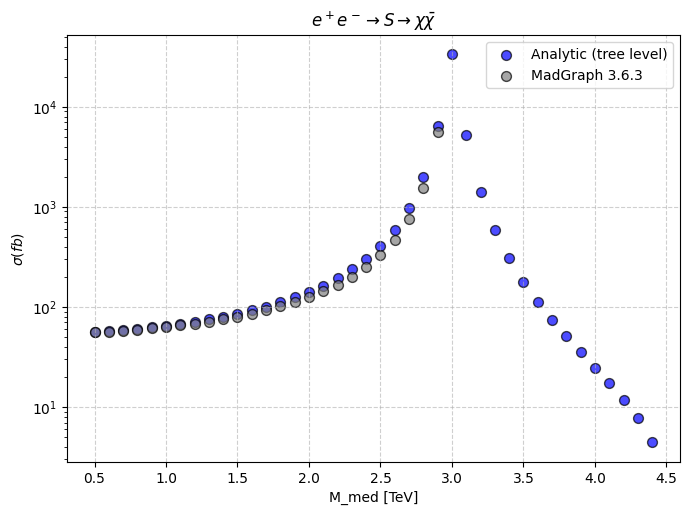

In [259]:

import matplotlib.pyplot as plt
fig, ax  = plt.subplots(figsize=(7, 5))
plot_columns(results, 'M_med', "cross", xlabel='M_med [TeV]', ylabel=r"$\sigma (fb)$", log=True, color='blue', label='Analytic (tree level)', fig = fig, ax = ax)
plot_columns(mg5_results, 'M_med', "cross", xlabel='M_med [TeV]', ylabel=r"$\sigma (fb)$", log=True, color='gray', label='MadGraph 3.6.3', fig = fig, ax = ax )

ax.legend()

ax.grid(True, linestyle="--", alpha=0.6)
fig.tight_layout()
ax.set_title(r'$e^+ e^- \to S \to \chi \bar \chi$')
fig.show()

In [41]:
sigma_data = np.array(list(sigmaz_pdf[:, :]), dtype=float)


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [44]:
sigma_data * gp.brn

NameError: name 'sigma_data' is not defined

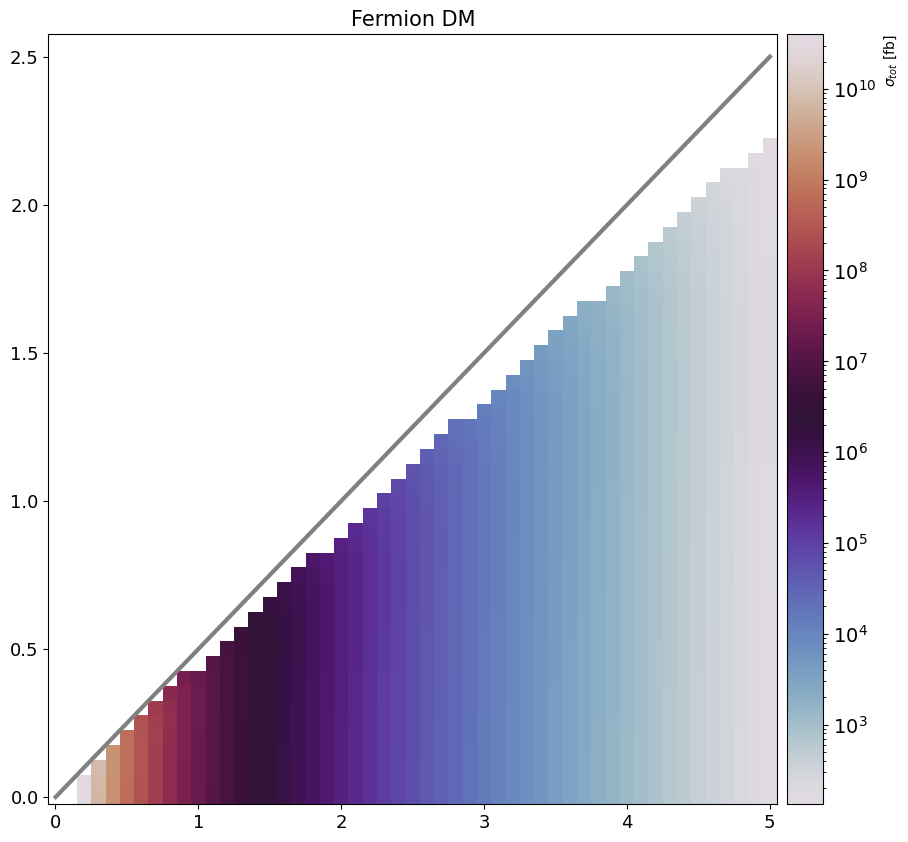

In [21]:
# import app.utils.colorb_2D as cb2d
# python parameters
import matplotlib.colorbar as colorb
from matplotlib import colors
import numpy as np
from mpl_toolkits.axes_grid1 import ImageGrid
import matplotlib.pyplot as plt

cmap = 'twilight'

process = 'ee'
fignumber = 0
fig = plt.figure(figsize=(10,10))
ax = ImageGrid(fig, 111,          # as in plt.subplot(111)
        nrows_ncols=(1,1),
        axes_pad=(0.30, 0.0),
        share_all=True,
        cbar_location="right",
        cbar_mode="single",
        cbar_size="5%",
        cbar_pad=0.10,
        aspect=False
        )
    # Colorbar

scale = colors.LogNorm()
fsize = 10
im = ax[fignumber].pcolormesh(Mmed_grid, mx_grid, sigma_data*gp.brn, norm=scale, cmap= cmap, rasterized=True) ## heat map of xsec
ax[0].cax.cla()
cb = colorb.Colorbar(ax[0].cax, im)
# ax[0].cax.toggle_label(True)
cb.solids.set_rasterized(True)
cb.set_label(r'$\sigma_{tot}$ [fb]', fontsize = fsize, loc='top')  ## color bar label 
cb.ax.tick_params(labelsize=fsize+4)

# ######################################################################################
# M/2 line #
x1, y1 = [Mmed_grid[0][0], Mmed_grid[0][-1]], [Mmed_grid[0][0]/2, Mmed_grid[0][-1]/2]
ab, = ax[fignumber].plot(x1, y1, linewidth=3, color='grey', linestyle='solid', label=r'${m_\chi } = {M_{med} }/2$')


textstr = '\n'.join((
    r'$g_{SM} = %1.2f$, $g_{\chi} = %1.0f$' %(0, gp.gx0),
    ))
ax[0].plot([], [], label=textstr, color = 'None')

textstr = textstr + '\n' + gp.ee_qq[process]
## Plot Labels ##
if fignumber == 0:
    #ab, = plt.plot(x1, y1, linewidth=3, color='gray', linestyle='solid', label=r'${m_\chi } = {M_{med} }/2$', rasterized=True)
    ac, = plt.plot(0, 0, linewidth=2.5, color='red', linestyle='dashed', label=r'$2{m_\chi } = 0.8{M_{med} }$', rasterized=True)
    ad, = plt.plot([], [], label=textstr, color = 'None')
    #af, = plt.plot([], [], linewidth=1, color='blue', linestyle='solid', label='CMS - arXiv:2107.13021', rasterized=True)
    ax[fignumber].tick_params(axis="y", labelsize = fsize + 3)

ax[fignumber].set_title(f'{dmname} DM', fontsize = fsize+5)
ax[fignumber].tick_params(axis="x", labelsize=fsize+3)



